In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



we will use support vector machines, decision trees and random forests.

In [3]:
raw = pd.read_csv('iris.csv')

In [4]:
raw

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
raw.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
print(raw.duplicated().sum())

3


In [33]:
raw.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
raw.tail(50)

,sepal_length,sepal_width,petal_length,petal_width,species
100,6.3,3.3,6.0,2.5,Iris-virginica
101,5.8,2.7,5.1,1.9,Iris-virginica
102,7.1,3.0,5.9,2.1,Iris-virginica
103,6.3,2.9,5.6,1.8,Iris-virginica
104,6.5,3.0,5.8,2.2,Iris-virginica
105,7.6,3.0,6.6,2.1,Iris-virginica
106,4.9,2.5,4.5,1.7,Iris-virginica
107,7.3,2.9,6.3,1.8,Iris-virginica
108,6.7,2.5,5.8,1.8,Iris-virginica
109,7.2,3.6,6.1,2.5,Iris-virginica


In [7]:
raw.shape

(150, 5)

In [8]:
raw.info

<bound method DataFrame.info of      sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]>

In [10]:
raw.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
raw['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

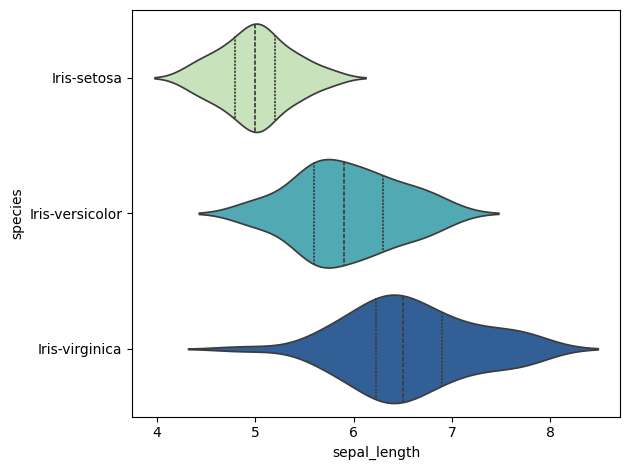

In [24]:
sns.violinplot(y='species', x='sepal_length', data=raw, inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

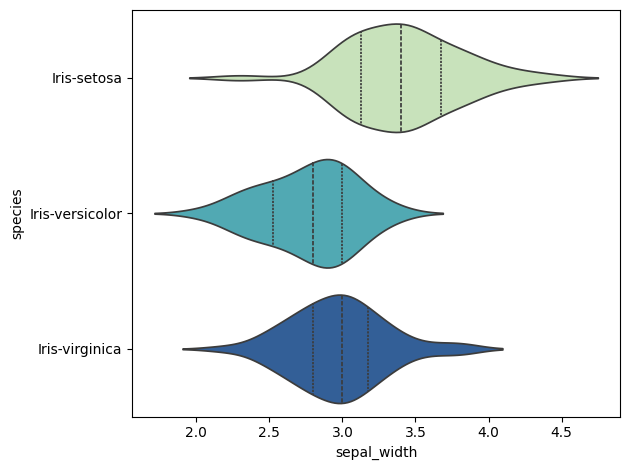

In [23]:
sns.violinplot(y='species', x='sepal_width',data=raw,inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

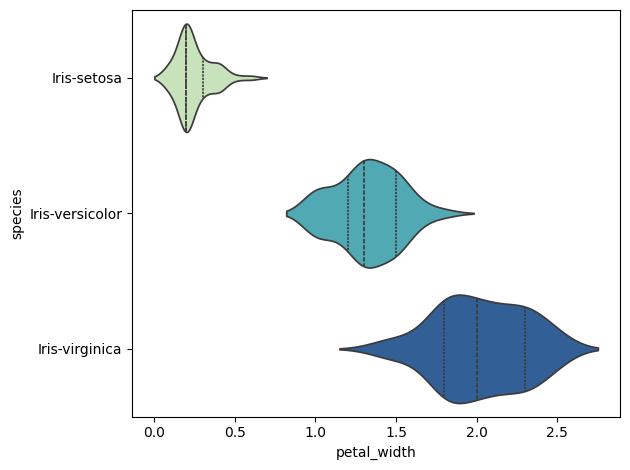

In [22]:
sns.violinplot(y='species', x='petal_width',data=raw,inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

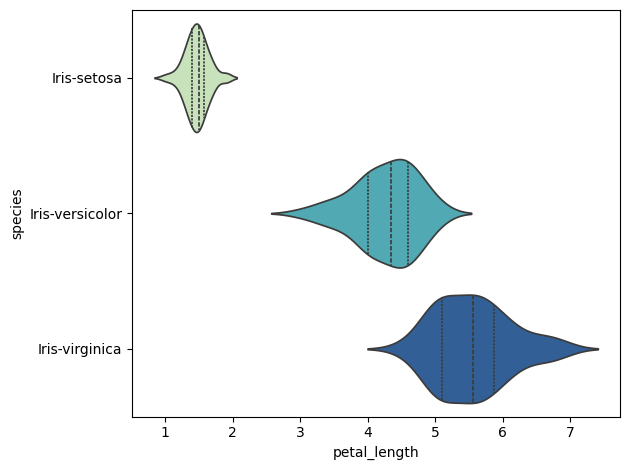

In [21]:
sns.violinplot(y='species', x='petal_length',data=raw,inner='quartile', hue='species',palette="YlGnBu")
plt.tight_layout()

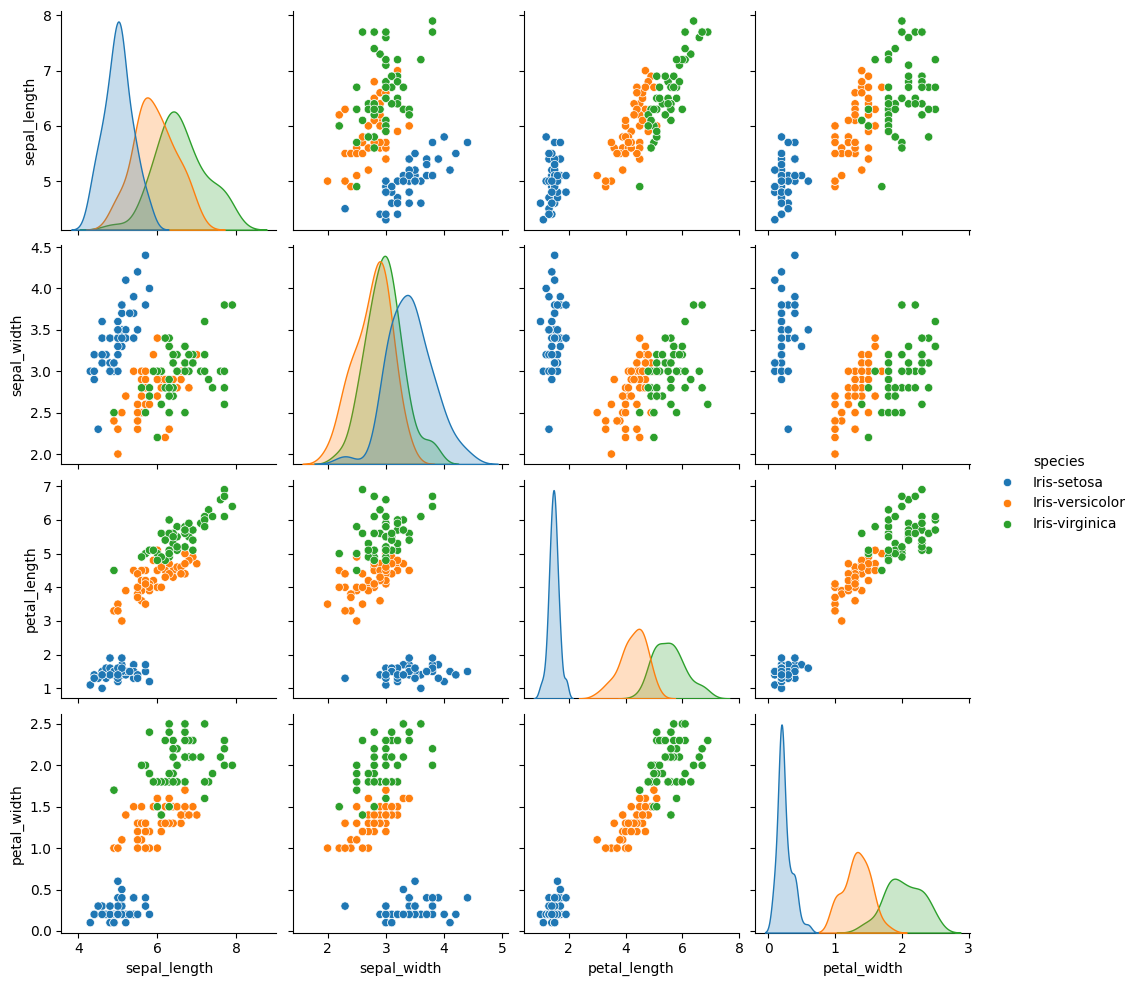

In [26]:
sns.pairplot(raw,hue='species')
plt.show()

<Axes: >

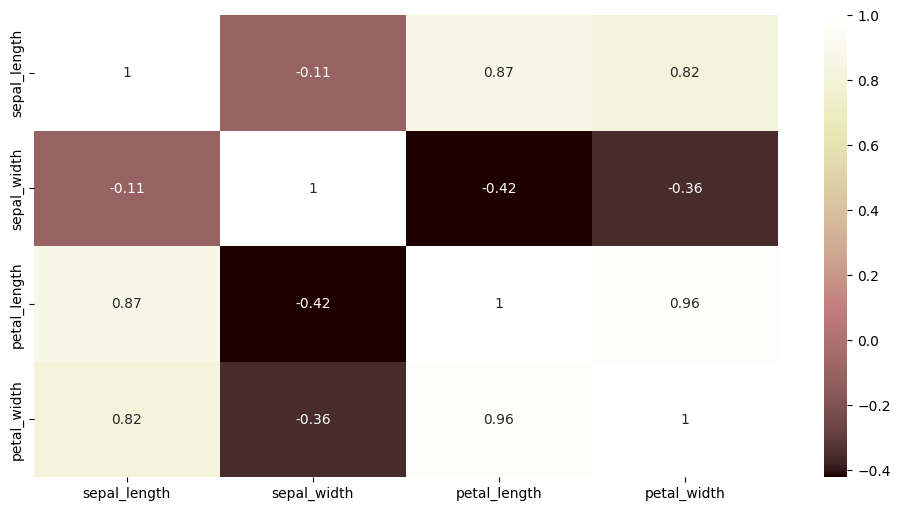

In [30]:
plt.figure(figsize=(12,6))
numerical_data = raw.select_dtypes(include=['float64','int64'])
sns.heatmap(numerical_data.corr(),annot=True, cmap='pink')

In [35]:
for i in raw.columns.tolist():
    print("No. of unique values in",i,"is",raw[i].nunique())

No. of unique values in sepal_length is 35
No. of unique values in sepal_width is 23
No. of unique values in petal_length is 43
No. of unique values in petal_width is 22
No. of unique values in species is 3


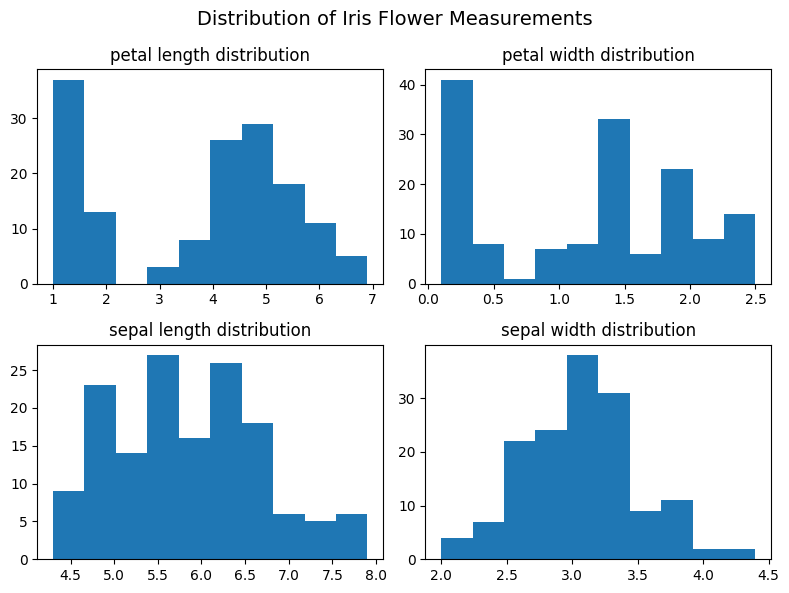

In [43]:
plt.figure(figsize=(8,6))
plt.suptitle('Distribution of Iris Flower Measurements', fontsize=14)

plt.subplot(2,2,1)
plt.hist(raw['petal_length'])
plt.title('petal length distribution')

plt.subplot(2,2,2)
plt.hist(raw['petal_width'])
plt.title('petal width distribution')

plt.subplot(2,2,3)
plt.hist(raw['sepal_length'])
plt.title('sepal length distribution')

plt.subplot(2,2,4)
plt.hist(raw['sepal_width'])
plt.title('sepal width distribution')

plt.tight_layout()  
plt.show()